In [2]:
!pip install -q kagglehub

import kagglehub
import tensorflow as tf
import os, shutil
import numpy as np
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing import image
import matplotlib.pyplot as plt

In [3]:
path = kagglehub.dataset_download("kaanerkez/waste-classfication-dataset")

base_path = os.path.join(path, "balanced_waste_images")

print(os.listdir(base_path))

100%|██████████| 56.5M/56.5M [00:00<00:00, 89.2MB/s]

Extracting files...


['Keyboard', 'PCB', 'paper', 'metal', 'Battery', 'Microwave', 'glass', 'Mobile', 'Player', 'cardboard', 'Printer', 'Mouse', 'Television', 'Washing Machine', 'trash', 'plastic', 'organic']


In [4]:
dst_path = "/content/waste_dataset"

shutil.copytree(base_path, dst_path, dirs_exist_ok=True)

base_path = dst_path

print("Dataset ready at:", base_path)

Dataset ready at: /content/waste_dataset


In [5]:
train_dir = "/content/dataset/train"
test_dir = "/content/dataset/test"

os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)

for cls in os.listdir(base_path):
    cls_path = os.path.join(base_path, cls)

    if os.path.isdir(cls_path):
        images = os.listdir(cls_path)
        train_imgs, test_imgs = train_test_split(images, test_size=0.2, random_state=42)

        os.makedirs(os.path.join(train_dir, cls), exist_ok=True)
        os.makedirs(os.path.join(test_dir, cls), exist_ok=True)

        for img in train_imgs:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(train_dir, cls, img))

        for img in test_imgs:
            shutil.copy(os.path.join(cls_path, img),
                        os.path.join(test_dir, cls, img))

In [6]:
img_size = (224, 224)
batch_size = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size
)

class_names = train_data.class_names
print(class_names)

Found 5423 files belonging to 17 classes.
Found 1359 files belonging to 17 classes.
['Battery', 'Keyboard', 'Microwave', 'Mobile', 'Mouse', 'PCB', 'Player', 'Printer', 'Television', 'Washing Machine', 'cardboard', 'glass', 'metal', 'organic', 'paper', 'plastic', 'trash']


In [7]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.cache().shuffle(1000).prefetch(AUTOTUNE)
test_data = test_data.cache().prefetch(AUTOTUNE)

In [8]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.Rescaling(1./255),

    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),

    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation='softmax')
])

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [9]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [10]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=2
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "best_model.h5",
        save_best_only=True
    )
]

In [11]:
history = model.fit(
    train_data,
    validation_data=test_data,
    epochs=10,
    callbacks=callbacks
)

Epoch 1/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4337 - loss: 2.0487

170/170 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.5689 - loss: 1.4765 - val_accuracy: 0.8521 - val_loss: 0.4811 - learning_rate: 0.0010
Epoch 2/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6961 - loss: 0.9551

170/170 ━━━━━━━━━━━━━━━━━━━━ 332s 2s/step - accuracy: 0.7168 - loss: 0.8826 - val_accuracy: 0.8771 - val_loss: 0.3860 - learning_rate: 0.0010
Epoch 3/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.7482 - loss: 0.7777

170/170 ━━━━━━━━━━━━━━━━━━━━ 330s 2s/step - accuracy: 0.7575 - loss: 0.7600 - val_accuracy: 0.8911 - val_loss: 0.3197 - learning_rate: 0.0010
Epoch 4/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.7894 - loss: 0.6508 - val_accuracy: 0.8823 - val_loss: 0.3420 - learning_rate: 0.0010
Epoch 5/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.8023 - loss: 0.6043 - val_accuracy: 0.8882 - val_loss: 0.3262 - learning_rate: 0.0010
Epoch 6/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8295 - loss: 0.4955

170/170 ━━━━━━━━━━━━━━━━━━━━ 410s 2s/step - accuracy: 0.8350 - loss: 0.4956 - val_accuracy: 0.8999 - val_loss: 0.3029 - learning_rate: 3.0000e-04
Epoch 7/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8354 - loss: 0.4911

170/170 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8388 - loss: 0.4847 - val_accuracy: 0.9021 - val_loss: 0.2944 - learning_rate: 3.0000e-04
Epoch 8/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8419 - loss: 0.4796

170/170 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.8403 - loss: 0.4810 - val_accuracy: 0.9021 - val_loss: 0.2902 - learning_rate: 3.0000e-04
Epoch 9/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.8544 - loss: 0.4236

170/170 ━━━━━━━━━━━━━━━━━━━━ 331s 2s/step - accuracy: 0.8547 - loss: 0.4340 - val_accuracy: 0.9021 - val_loss: 0.2849 - learning_rate: 3.0000e-04
Epoch 10/10
170/170 ━━━━━━━━━━━━━━━━━━━━ 381s 2s/step - accuracy: 0.8536 - loss: 0.4330 - val_accuracy: 0.8992 - val_loss: 0.2919 - learning_rate: 3.0000e-04


In [12]:
base_model.trainable = True

for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_fine = model.fit(
    train_data,
    validation_data=test_data,
    epochs=5,
    callbacks=callbacks
)

Epoch 1/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 433s 2s/step - accuracy: 0.7367 - loss: 0.8198 - val_accuracy: 0.8896 - val_loss: 0.3327 - learning_rate: 1.0000e-05
Epoch 2/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.7605 - loss: 0.7177 - val_accuracy: 0.8823 - val_loss: 0.3430 - learning_rate: 1.0000e-05
Epoch 3/5
170/170 ━━━━━━━━━━━━━━━━━━━━ 396s 2s/step - accuracy: 0.7785 - loss: 0.6566 - val_accuracy: 0.8896 - val_loss: 0.3318 - learning_rate: 3.0000e-06


In [13]:
loss, acc = model.evaluate(test_data)
print("Final Accuracy:", acc)

43/43 ━━━━━━━━━━━━━━━━━━━━ 56s 1s/step - accuracy: 0.8896 - loss: 0.3327
Final Accuracy: 0.8896247148513794


Saving i13.jpg to i13.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step


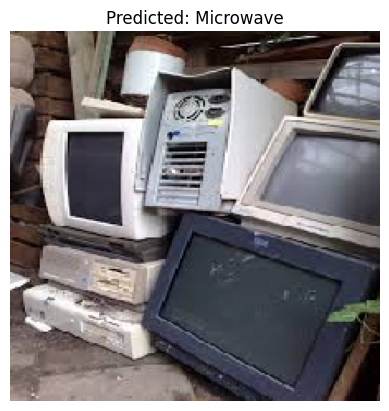

In [19]:
from google.colab import files

def predict_upload():
    uploaded = files.upload()

    for img_name in uploaded.keys():
        img = image.load_img(img_name, target_size=(224,224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)

        pred = model.predict(img_array)

        plt.imshow(img)
        plt.title("Predicted: " + class_names[np.argmax(pred)])
        plt.axis("off")
        plt.show()

predict_upload()